# Customer Segmentation using Clustering

## Objective
The objective of this notebook is to apply **unsupervised learning techniques** to group similar customers together based on their characteristics.

We will implement:

- K-Means Clustering
- Hierarchical Clustering

The dataset contains information about customers such as **Age, Annual Income, and Spending Score**.

## Importing Required Libraries

We import the necessary Python libraries used for data manipulation, visualization, and clustering.


In [7]:

import pandas as pd
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt



## Loading Dataset

The dataset is stored in **Google Drive**.  
We load it directly using the file URL and convert it into a Pandas DataFrame.

In [8]:
url = "https://drive.google.com/uc?id=11A97SOIw-mr_Uis4F3Yg-NiBcz8m7xay"

df = pd.read_csv(url)

df.head()

,CustomerID,Age,Annual_Income,Spending_Score
0,1,56,22695,62
1,2,46,68190,58
2,3,32,25258,52
3,4,60,107538,12
4,5,25,59504,39


## K-Means Clustering

K-Means is an unsupervised learning algorithm used to partition data into **K clusters**.

Steps involved:
1. Choose number of clusters (K)
2. Initialize centroids
3. Assign points to nearest centroid
4. Update centroid positions
5. Repeat until convergence

In [9]:
from sklearn.cluster import KMeans

X = df[['Age','Annual_Income','Spending_Score']]

kmeans = KMeans(n_clusters=3, random_state=42)

df['KMeans_Cluster'] = kmeans.fit_predict(X)

df.head()

,CustomerID,Age,Annual_Income,Spending_Score,KMeans_Cluster
0,1,56,22695,62,1
1,2,46,68190,58,2
2,3,32,25258,52,1
3,4,60,107538,12,0
4,5,25,59504,39,2


## Cluster Visualization

We visualize the clusters using a scatter plot.

Each color represents a **different customer group identified by K-Means**.

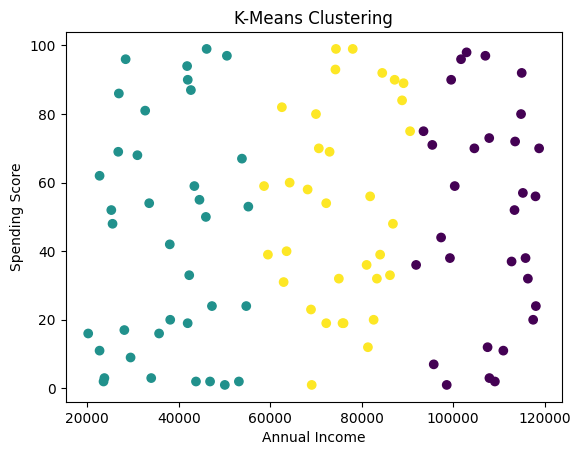

In [10]:
plt.scatter(df['Annual_Income'], df['Spending_Score'], c=df['KMeans_Cluster'])

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("K-Means Clustering")

plt.show()

## Hierarchical Clustering

Hierarchical clustering builds a hierarchy of clusters.

Unlike K-Means, it **does not require specifying the number of clusters beforehand**.

There are two main approaches:

- Agglomerative (bottom-up)
- Divisive (top-down)

In this notebook we use **Agglomerative Clustering**.

In [11]:


hc = AgglomerativeClustering(n_clusters=3)

df['Hierarchical_Cluster'] = hc.fit_predict(X)

df.head()

,CustomerID,Age,Annual_Income,Spending_Score,KMeans_Cluster,Hierarchical_Cluster
0,1,56,22695,62,1,1
1,2,46,68190,58,2,2
2,3,32,25258,52,1,1
3,4,60,107538,12,0,0
4,5,25,59504,39,2,2


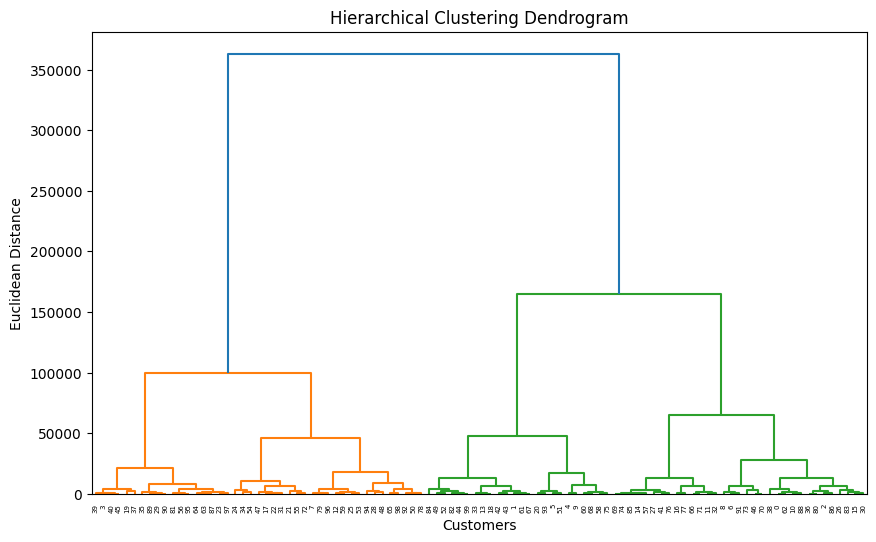

In [14]:
from scipy.cluster.hierarchy import dendrogram, linkage

import matplotlib.pyplot as plt

# Using selected features
X = df[['Age','Annual_Income','Spending_Score']]

# Perform hierarchical clustering
linked = linkage(X, method='ward')

# Plot dendrogram
plt.figure(figsize=(10,6))

dendrogram(linked, leaf_rotation=90)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Euclidean Distance")

plt.show()

## Conclusion

In this notebook we applied two unsupervised learning techniques:

1. **K-Means Clustering**
2. **Hierarchical Clustering**

Both methods grouped customers based on similar characteristics such as income and spending behaviour.

Clustering helps businesses perform:
- customer segmentation
- targeted marketing
- personalized services